Exercise 1: K-Nearest Neighbor

Let us implement the algorithm with the help of the 'Mobile.csv' dataset.

It contains data about customers “Age”, “EstimatedSalary”, “Purchased” .

Download the dataset from the shared folder.


Predict if the customer will purchase a mobile or not.

Load data : mobile.csv
Look inside the dataset by finding information.
Draw scatter plot of purchased and not_purchased value with respect to Age and EstimatedSalary.
Do Feature engineering (normalize the Age and EstimatedSalary columns)
Split the dataset into train and test data
Build the kNN model with k=5,k=3,k=7.
Evaluate model performance on train and test sets with different value of k.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [3]:
df = pd.read_csv("../data/Mobile.csv")

In [4]:
df.head()


,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0


In [6]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Age              400 non-null    int64
 1   EstimatedSalary  400 non-null    int64
 2   Purchased        400 non-null    int64
dtypes: int64(3)
memory usage: 9.5 KB


In [7]:
df.isnull().sum()

Age                0
EstimatedSalary    0
Purchased          0
dtype: int64

In [8]:
df.describe()

,Age,EstimatedSalary,Purchased
count,400.000000,400.000000,400.000000
mean,37.655000,69742.500000,0.357500
std,10.482877,34096.960282,0.479864
min,18.000000,15000.000000,0.000000
25%,29.750000,43000.000000,0.000000
50%,37.000000,70000.000000,0.000000
75%,46.000000,88000.000000,1.000000
max,60.000000,150000.000000,1.000000


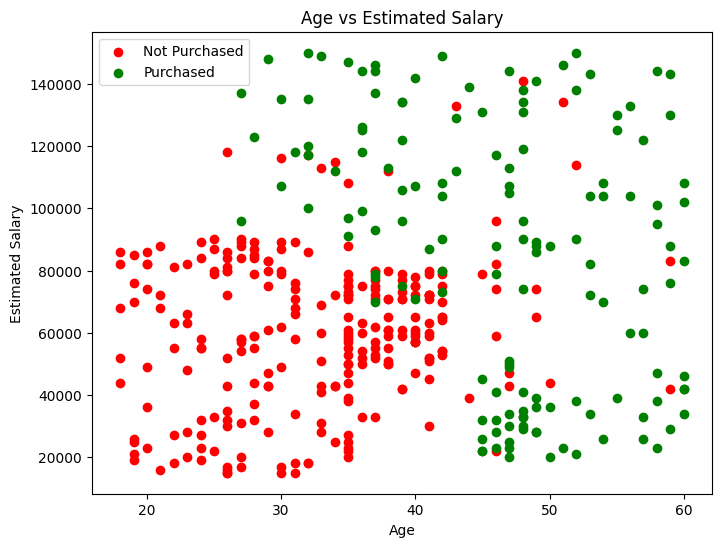

In [9]:
plt.figure(figsize=(8,6))

plt.scatter(df[df['Purchased']==0]['Age'],
            df[df['Purchased']==0]['EstimatedSalary'],
            color='red', label='Not Purchased')

plt.scatter(df[df['Purchased']==1]['Age'],
            df[df['Purchased']==1]['EstimatedSalary'],
            color='green', label='Purchased')

plt.xlabel("Age")
plt.ylabel("Estimated Salary")
plt.legend()
plt.title("Age vs Estimated Salary")
plt.show()

In [10]:
X = df[['Age', 'EstimatedSalary']]
y = df['Purchased']

In [11]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, 
    test_size=0.25,
    random_state=42
)

In [13]:
knn3 = KNeighborsClassifier(n_neighbors=3)
knn3.fit(X_train, y_train)

y_train_pred3 = knn3.predict(X_train)
y_test_pred3 = knn3.predict(X_test)

print("K=3")
print("Train Accuracy:", accuracy_score(y_train, y_train_pred3))
print("Test Accuracy:", accuracy_score(y_test, y_test_pred3))

K=3
Train Accuracy: 0.9266666666666666
Test Accuracy: 0.92


In [ ]:
knn5 = KNeighborsClassifier(n_neighbors=5)
knn5.fit(X_train, y_train)

y_train_pred5 = knn5.predict(X_train)
y_test_pred5 = knn5.predict(X_test)

print("K=5")
print("Train Accuracy:", accuracy_score(y_train, y_train_pred5))
print("Test Accuracy:", accuracy_score(y_test, y_test_pred5))

K=5
Train Accuracy: 0.91
Test Accuracy: 0.93


In [15]:
knn7 = KNeighborsClassifier(n_neighbors=7)
knn7.fit(X_train, y_train)

y_train_pred7 = knn7.predict(X_train)
y_test_pred7 = knn7.predict(X_test)

print("K=7")
print("Train Accuracy:", accuracy_score(y_train, y_train_pred7))
print("Test Accuracy:", accuracy_score(y_test, y_test_pred7))

K=7
Train Accuracy: 0.9166666666666666
Test Accuracy: 0.93


In [16]:
confusion_matrix(y_test, y_test_pred5)

array([[59,  4],
       [ 3, 34]])

In [17]:
print(classification_report(y_test, y_test_pred5))

              precision    recall  f1-score   support

           0       0.95      0.94      0.94        63
           1       0.89      0.92      0.91        37

    accuracy                           0.93       100
   macro avg       0.92      0.93      0.93       100
weighted avg       0.93      0.93      0.93       100



Exercise 2: SVM for classification

Consider the Iris dataset which provides measurements of sepal length, sepal width, petal length, and petal width for 50 flowers from each of 3 species. Total rows are 150.


Create Binary Class SVM model
Reading input from csv file (iris.csv)
Do Feature Engineering
Create a new column in the dataframe (v_nv), that distinguishes the species - 'versicolor'(marked by 0) from rest.
Build Model
Visualize Model using mlxtend

Create Multi Class SVM model
Reading input from csv file (iris.csv)
Do Feature Engineering
Encode the species column with numerical values. And replace label 'setosa' with '0', 'versicolor' with '1' and 'virginica' with '2'.
Build Multiclass Model using SVM
Visualize Model using mlxtend

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix

from mlxtend.plotting import plot_decision_regions

In [21]:
df = pd.read_csv("../data/iris.csv")
df.head()

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [25]:

df.info()
df.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Sepal.Length  150 non-null    float64
 1   Sepal.Width   150 non-null    float64
 2   Petal.Length  150 non-null    float64
 3   Petal.Width   150 non-null    float64
 4   Species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


Index(['Sepal.Length', 'Sepal.Width', 'Petal.Length', 'Petal.Width',
       'Species'],
      dtype='object')

In [28]:
df['v_nv'] = (df['Species'] != 'versicolor').astype(int)

In [30]:
df[['Species','v_nv']].head()


,Species,v_nv
0,setosa,1
1,setosa,1
2,setosa,1
3,setosa,1
4,setosa,1


In [31]:
X = df[['Petal.Length', 'Petal.Width']].values
y = df['v_nv'].values

In [32]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X = scaler.fit_transform(X)

In [33]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42)

In [34]:
from sklearn.svm import SVC

svm_binary = SVC(kernel='linear')
svm_binary.fit(X_train, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [35]:
from sklearn.metrics import accuracy_score

y_pred = svm_binary.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.7111111111111111


In [36]:
df['Species'] = df['Species'].replace({
    'setosa': 0,
    'versicolor': 1,
    'virginica': 2
})

C:\Users\user\AppData\Local\Temp\ipykernel_1504\2708756074.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Species'] = df['Species'].replace({


In [38]:
X = df[['Petal.Length', 'Petal.Width']].values
y = df['Species'].values

In [40]:
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [41]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42)

In [42]:
svm_multi = SVC(kernel='linear')
svm_multi.fit(X_train, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [43]:
y_pred = svm_multi.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 1.0


In [44]:
df.info()
df.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Sepal.Length  150 non-null    float64
 1   Sepal.Width   150 non-null    float64
 2   Petal.Length  150 non-null    float64
 3   Petal.Width   150 non-null    float64
 4   Species       150 non-null    int64  
 5   v_nv          150 non-null    int64  
dtypes: float64(4), int64(2)
memory usage: 7.2 KB


Index(['Sepal.Length', 'Sepal.Width', 'Petal.Length', 'Petal.Width', 'Species',
       'v_nv'],
      dtype='object')

In [45]:
df[['Species','v_nv']].head()

,Species,v_nv
0,0,1
1,0,1
2,0,1
3,0,1
4,0,1


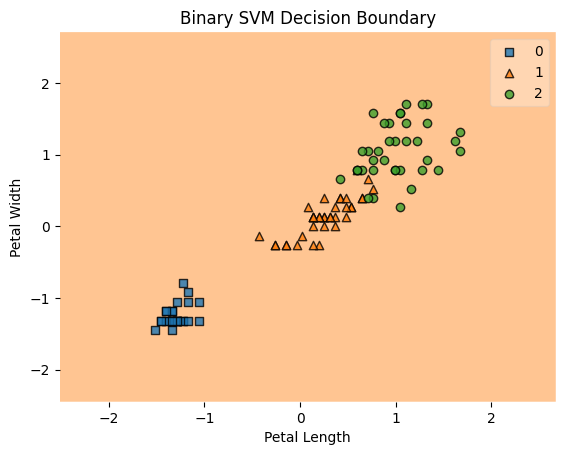

In [46]:
plot_decision_regions(X_train, y_train, clf=svm_binary)
plt.xlabel('Petal Length')
plt.ylabel('Petal Width')
plt.title('Binary SVM Decision Boundary')
plt.show()

In [47]:
X = df[['Petal.Length', 'Petal.Width']].values
y = df['Species'].values

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X = scaler.fit_transform(X)

from sklearn.svm import SVC
model = SVC(kernel='linear')
model.fit(X, y)

# Testing on same data
y_pred = model.predict(X)

from sklearn.metrics import accuracy_score
print("Accuracy:", accuracy_score(y, y_pred))

Accuracy: 0.9533333333333334


In [48]:
from sklearn.model_selection import cross_val_score
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
import numpy as np

X = df[['Petal.Length', 'Petal.Width']].values
y = df['Species'].values

scaler = StandardScaler()
X = scaler.fit_transform(X)

model = SVC(kernel='linear')

scores = cross_val_score(model, X, y, cv=5)

print("Cross Validation Scores:", scores)
print("Average Accuracy:", np.mean(scores))

Cross Validation Scores: [0.96666667 0.96666667 0.93333333 0.93333333 1.        ]
Average Accuracy: 0.96


In [49]:
model = SVC(kernel='linear')
model.fit(X, y)

y_pred = model.predict(X)

print("Accuracy (Same Data):", accuracy_score(y, y_pred))


Accuracy (Same Data): 0.9533333333333334


In [50]:
model = SVC(kernel='linear')

scores = cross_val_score(model, X, y, cv=5)

print("Cross Validation Scores:", scores)
print("Average Accuracy:", np.mean(scores))

Cross Validation Scores: [0.96666667 0.96666667 0.93333333 0.93333333 1.        ]
Average Accuracy: 0.96
